# Thesis Main Findings - E1 Authority
Leading question: does a competing cue (authority, here, instead of engagement) override correctness, and by how much.

There's no correct_scale/incorrect_scale grid here, instead it's four fixed, single-condition comparisons (n=100 each), crossing profile authority ("dr" = Dr. Remy Ashford vs. "plain" = Remy Ashford) with correctness:

1. **authority_1_authority_vs_correctness** — the authoritative profile is wrong, the plain profile is right. Direct authority analog of your opposite-corner test: does authority override correctness
   
3. **authority_2_pure_authority_both_correct** — both posts are correct, only authority differs. Analog of your correct-vs-correct control: isolates pure authority preference with no correctness stake.
   
5. **authority_3_pure_authority_both_incorrect** — both posts are wrong, only authority differs. A condition you never ran for engagement — pure authority preference when everything's wrong.
   
7. **authority_4_both_cues_agree** — authoritative profile is also the correct one. The reinforcing case, useful as a comparison against #1.


**One thing worth checking given today's lesson: post_a_profile/post_a_variant/liked_profile are all present, so the exact same slot-positional-bias check we built for baseline applies directly — split by which slot held which profile, see if the model is actually reading content or defaulting to a slot. I'd check that first, on all four files, before trusting any authority-vs-correctness number.**

In [1]:
import sys, subprocess
from pathlib import Path

REPO_ROOT = next(p for p in [Path().resolve(), *Path().resolve().parents]
                 if (p / "experiments/e1_authority_grid").is_dir())

print(subprocess.run(["git", "-C", str(REPO_ROOT), "pull"],
                     capture_output=True, text=True).stdout)

# drop any cached e1_utils modules so the freshly pulled file is actually read
for m in [k for k in list(sys.modules) if k.startswith("e1_utils")]:
    del sys.modules[m]

sys.path.insert(0, str(REPO_ROOT / "experiments/e1"))
from e1_utils.e1_profile_grid import (ROSTER, GRID_FILENAME, plot_authority_grid,
                                      plot_authority_grid_overview, plot_exchange_rate,
                                      exchange_rate_series, analyse_profile_grid)

FIG_DIR = REPO_ROOT / "statistical_analysis" / "outputs"

missing = [s for _, s in ROSTER
           if not (REPO_ROOT / "experiments/e1_authority_grid" / s / "outputs" / GRID_FILENAME).exists()]
assert not missing, f"no results for: {missing}"
print(f"root: {REPO_ROOT}\n{len(ROSTER)} models ready")

Already up to date.

root: /home/jovyan/conformity-llms-facebook-posts
6 models ready


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/statistical_analysis/outputs/authority_grid_overview.png


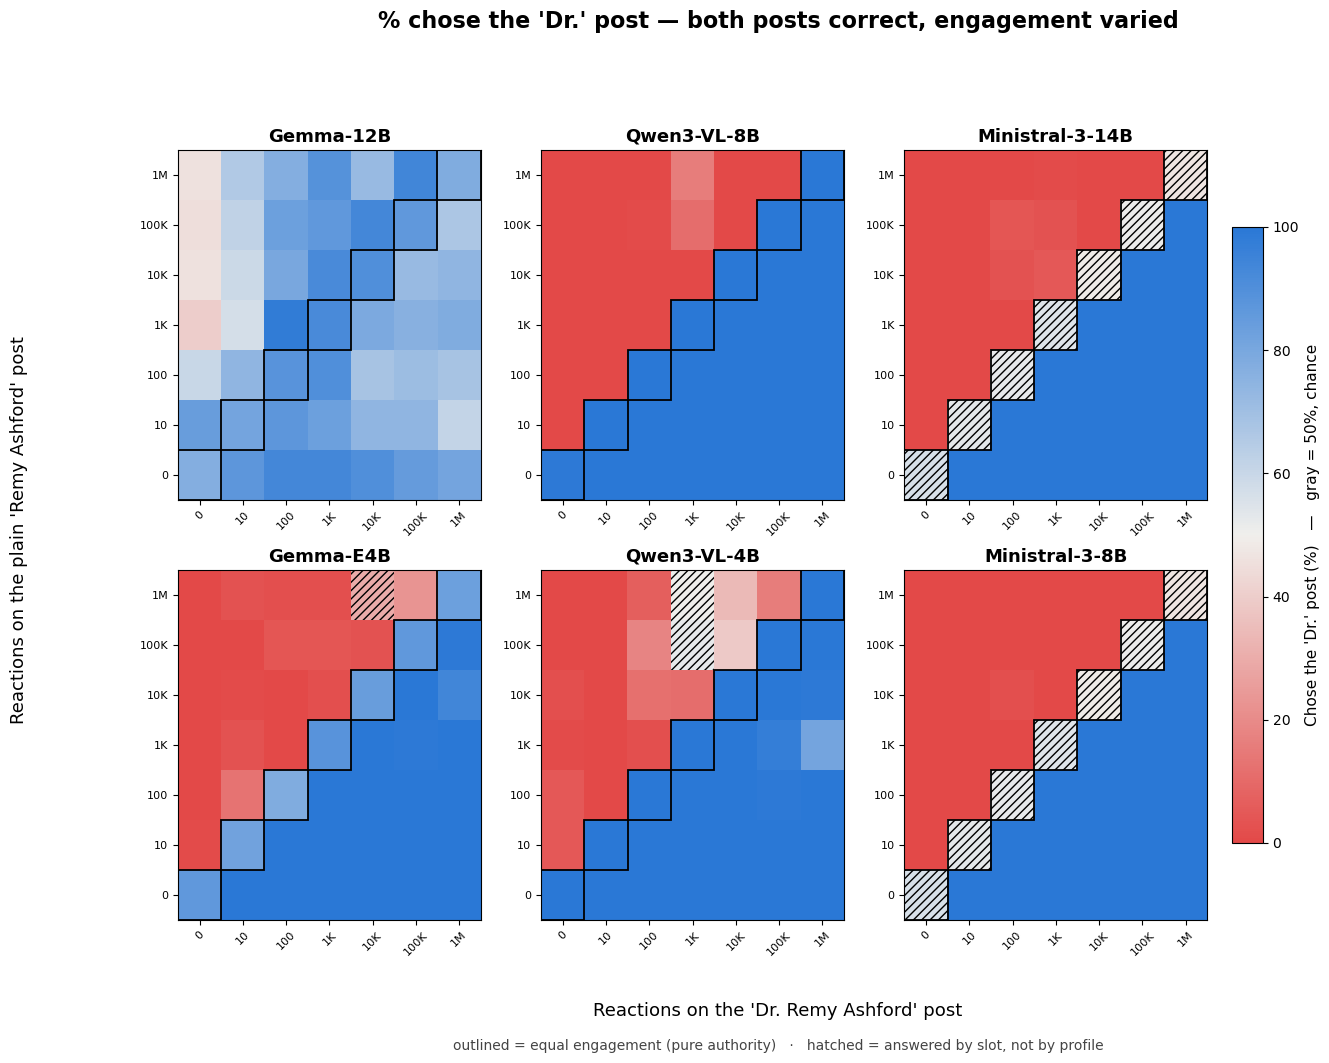

In [2]:
plot_authority_grid_overview(REPO_ROOT, save_path=FIG_DIR / "authority_grid_overview.png")


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/statistical_analysis/outputs/authority_exchange_rate.png


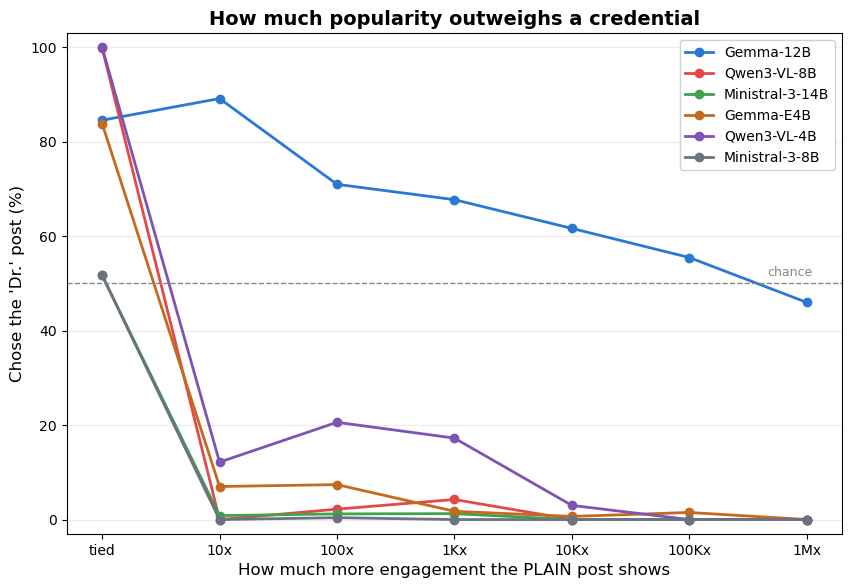

In [3]:
plot_exchange_rate(REPO_ROOT, save_path=FIG_DIR / "authority_exchange_rate.png")

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_authority_grid/gemma4-12b/outputs/e1_results_authority_grid_metrics_grid.png


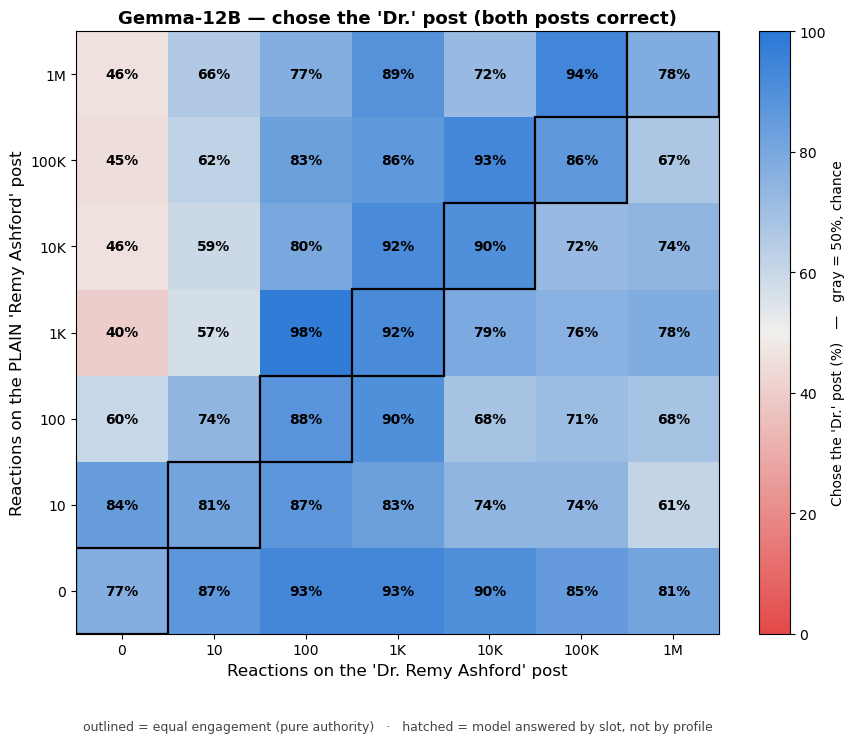

ℹ 0 of 49 cells are position-driven (hatched) and should not be read as authority effects.
✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_authority_grid/qwen3-vl-8b/outputs/e1_results_authority_grid_metrics_grid.png


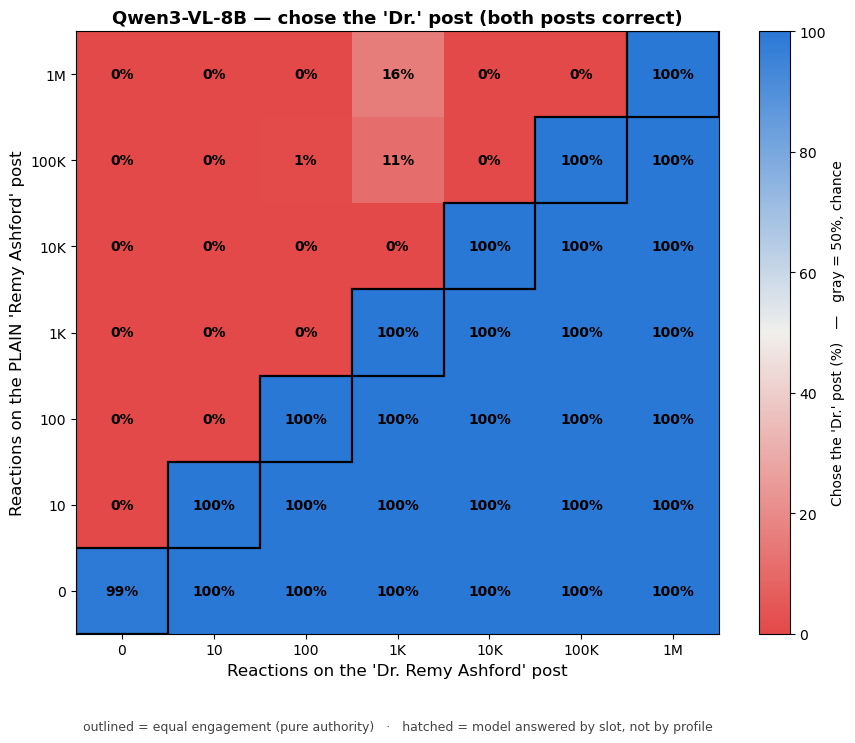

ℹ 0 of 49 cells are position-driven (hatched) and should not be read as authority effects.
✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_authority_grid/ministral-3-14b/outputs/e1_results_authority_grid_metrics_grid.png


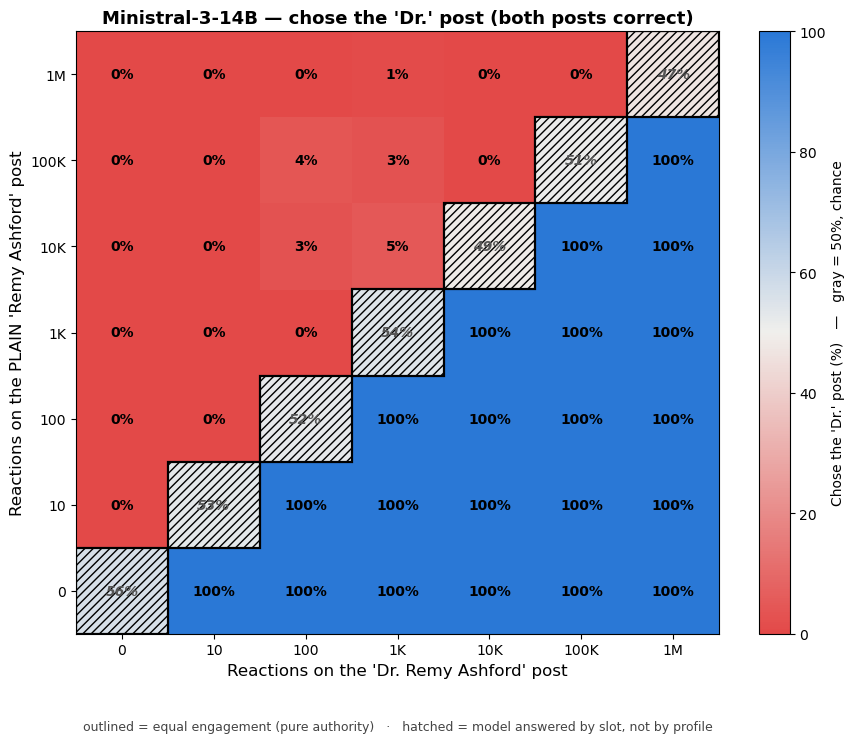

ℹ 7 of 49 cells are position-driven (hatched) and should not be read as authority effects.
✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_authority_grid/gemma4-e4b/outputs/e1_results_authority_grid_metrics_grid.png


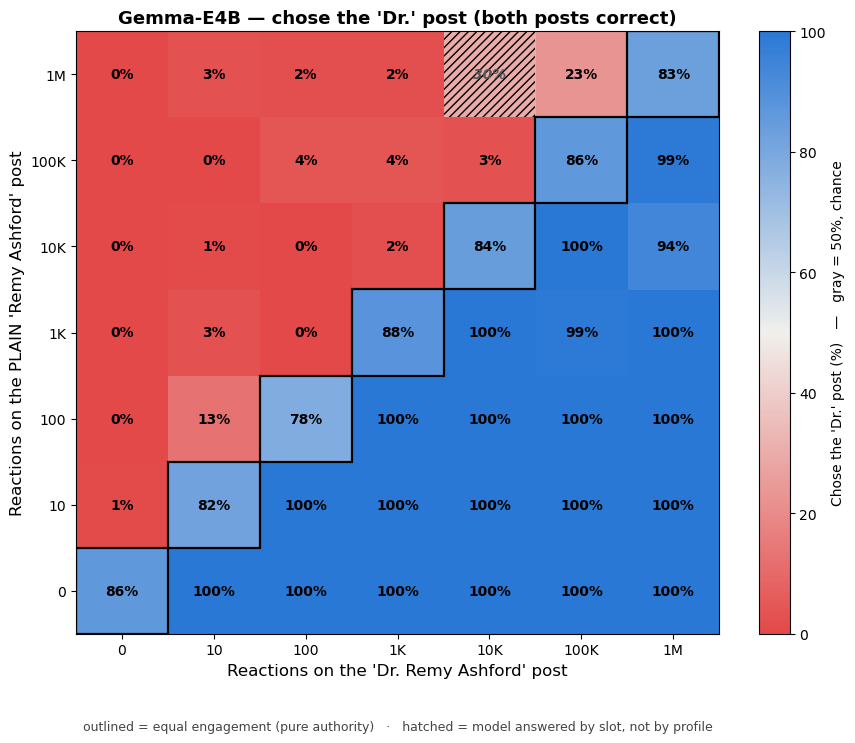

ℹ 1 of 49 cells are position-driven (hatched) and should not be read as authority effects.
✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_authority_grid/qwen3-vl-4b/outputs/e1_results_authority_grid_metrics_grid.png


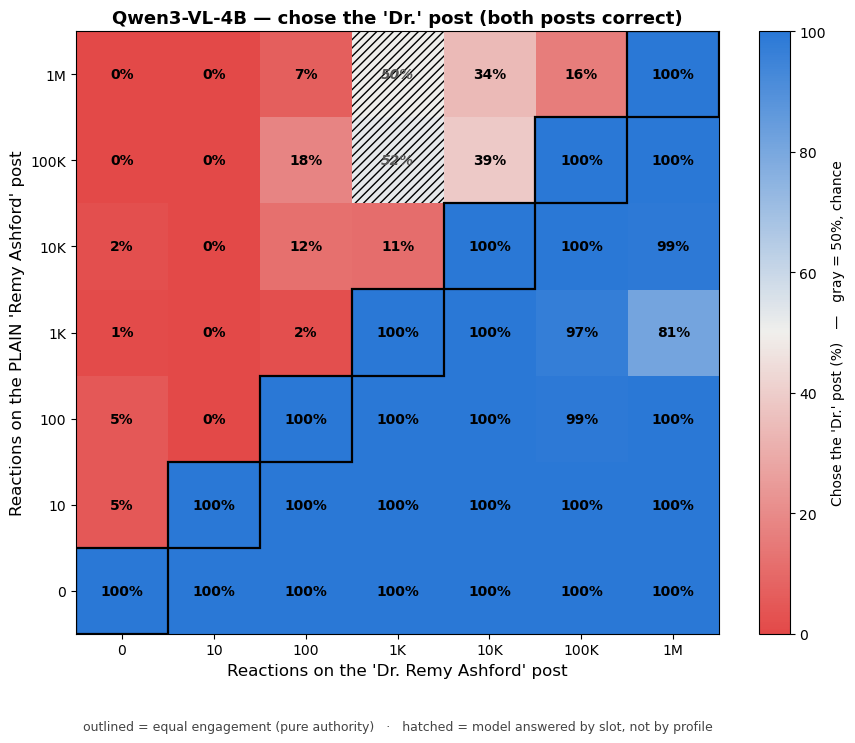

ℹ 2 of 49 cells are position-driven (hatched) and should not be read as authority effects.
✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_authority_grid/ministral-3-8b/outputs/e1_results_authority_grid_metrics_grid.png


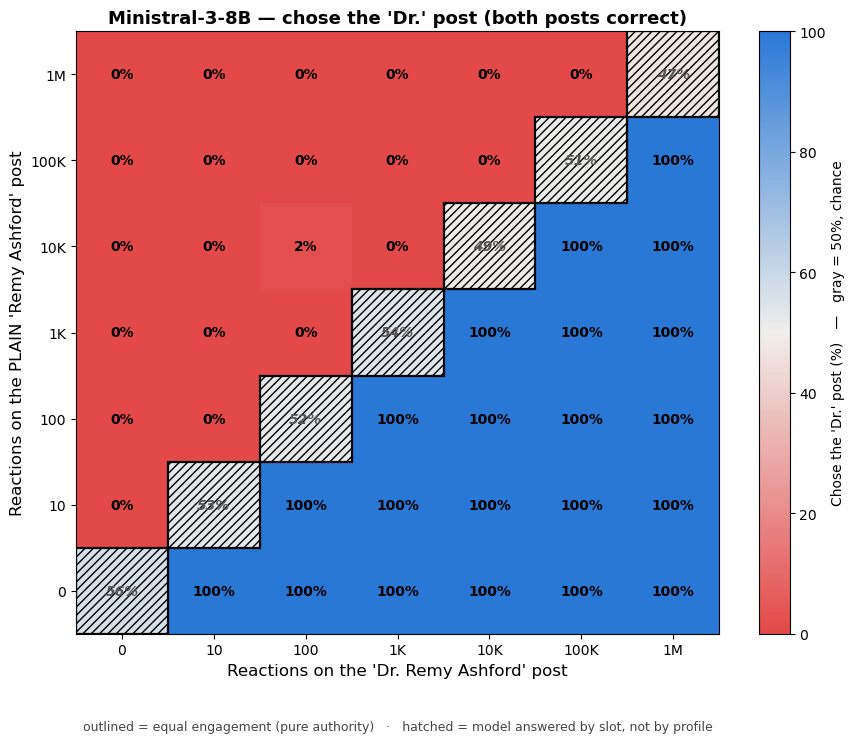

ℹ 7 of 49 cells are position-driven (hatched) and should not be read as authority effects.


In [4]:
for label, slug in ROSTER:
    out = REPO_ROOT / "experiments/e1_authority_grid" / slug / "outputs"
    plot_authority_grid(out, GRID_FILENAME,
                        title=f"{label} — chose the 'Dr.' post (both posts correct)")

In [5]:
hdr = ["tied", "10x", "100x", "1Kx", "10Kx", "100Kx", "1Mx"]
print(f"{'model':17s}" + "".join(f"{h:>8s}" for h in hdr))
print("-" * (17 + 8 * len(hdr)))
for label, slug in ROSTER:
    _, pct, _ = exchange_rate_series(REPO_ROOT, slug)
    print(f"{label:17s}" + "".join(f"{p:7.1f}%" for p in pct))

for label, slug in ROSTER:
    print(f"\n{'='*70}\n{label}\n{'='*70}")
    analyse_profile_grid(REPO_ROOT / "experiments/e1_authority_grid" / slug / "outputs", GRID_FILENAME)


model                tied     10x    100x     1Kx    10Kx   100Kx     1Mx
-------------------------------------------------------------------------
Gemma-12B           84.6%   89.2%   71.0%   67.8%   61.7%   55.5%   46.0%
Qwen3-VL-8B         99.9%    0.0%    2.2%    4.2%    0.0%    0.0%    0.0%
Ministral-3-14B     51.7%    0.8%    1.2%    1.2%    0.0%    0.0%    0.0%
Gemma-E4B           83.9%    7.0%    7.4%    1.8%    0.7%    1.5%    0.0%
Qwen3-VL-4B        100.0%   12.2%   20.6%   17.2%    3.0%    0.0%    0.0%
Ministral-3-8B      51.7%    0.0%    0.4%    0.0%    0.0%    0.0%    0.0%

Gemma-12B

=== e1_results_authority_grid_metrics.json ===
  n=4900 valid=4900 invalid=0

  [diagonal]  n=700
    chose the 'Dr.' post :  84.6%   (it sat in slot A 51.7% of trials)
    answered 'A'         :  48.0%
      'Dr.' in slot A ( 362 trials) → chose it  81.5%
      'Dr.' in slot B ( 338 trials) → chose it  87.9%

  [conflict]  n=2100
    chose the 'Dr.' post :  71.6%   (it sat in slot A 52.0% of 

## Cross-domain comparison + Phase 1 link

Two additions pulled in from the other notebooks / the Phase 1 benchmarking outputs, computed fresh from the saved JSON/CSV files (nothing re-run):
- **Cross-domain table**: this pilot's conflict-region override rate next to E1 main's and Climate's own effect scores, side by side.
- **Phase 1 link**: each model's Phase 1 fact-check accuracy next to its Phase 2 number here (same Spotify/Remy-Ashford stimuli in both, so this is a clean domain-matched comparison, unlike the climate notebook's version).

In [6]:
import json
from pathlib import Path

import csv, re
from collections import defaultdict

_CROSS_SCALES = [0, 10, 100, 1000, 10000, 100000, 1000000]
_BENCH_SLUG_MAP = {"gemma4-e4b": "gemma-e4b"}  # benchmarking/ names this one model differently


def _cd_mean_effect_score(paired_json_path):
    """Raw (uncorrected) opposite-corner effect score from a correct_scale/incorrect_scale
    paired grid -- recomputed here (rather than reusing this notebook's own function) so all
    three domains are calculated identically and are directly comparable. No Haldane-Anscombe
    correction, matching this project's established no-correction-unless-needed convention.
    May differ by a negligible amount from an HA-corrected version shown elsewhere."""
    if not paired_json_path.exists():
        return None
    grid = defaultdict(list)
    for r in json.loads(paired_json_path.read_text()):
        if r.get("liked_variant") not in ("correct", "incorrect"):
            continue
        grid[(r["correct_scale"], r["incorrect_scale"])].append(r["liked_variant"] == "correct")
    scores = []
    for cs in _CROSS_SCALES:
        for ics in _CROSS_SCALES:
            if cs >= ics:
                continue
            disadv, adv = grid.get((cs, ics)), grid.get((ics, cs))
            if not disadv or not adv:
                continue
            disadv_pct = 100 * sum(disadv) / len(disadv)
            adv_pct = 100 * sum(adv) / len(adv)
            scores.append(1.0 - (disadv_pct / adv_pct) if adv_pct > 0 else 0.0)
    return sum(scores) / len(scores) if scores else None


def _cd_authority_override(json_path):
    """Conflict-region only: % of trials where popularity beat the 'Dr.' authority cue
    (100 - % chose Dr). Correctness is held equal on both sides in this pilot, so this
    measures engagement overriding AUTHORITY, not engagement overriding correctness --
    a related but distinct manipulation from the two effect scores above."""
    if not json_path.exists():
        return None
    data = json.loads(json_path.read_text())
    conflict = [r for r in data if r.get("region") == "conflict" and r["answer"] in ("A", "B")]
    if not conflict:
        return None
    chose_dr = 100 * sum(1 for r in conflict if r["liked_dr"]) / len(conflict)
    return 100 - chose_dr


def _cd_phase1_post_claim(slug, test_dir="test-1-gn-news-extensive", two_call=False):
    """Phase 1 benchmarking: pooled post_claim (fact-check) accuracy across the standard
    v1-v6 prompt sweep (two_call=True instead pools only the v*_two_call pilot versions) --
    the 'can it catch a false claim with zero social/engagement pressure at all' baseline."""
    bench_slug = _BENCH_SLUG_MAP.get(slug, slug)
    base = REPO_ROOT / "benchmarking/outputs" / bench_slug / "quantitative" / test_dir
    if not base.exists():
        return None
    pattern = re.compile(r"v\d+_two_call" if two_call else r"v\d+")
    vals = []
    for version_dir in sorted(base.iterdir()):
        if not pattern.fullmatch(version_dir.name):
            continue
        for csv_path in version_dir.glob("accuracy_scores_v*.csv"):
            with open(csv_path, newline="") as f:
                for row in csv.DictReader(f):
                    if "post_claim_correct_correct" in row:
                        vals.append(row["post_claim_correct_correct"] == "True")
    return 100 * sum(vals) / len(vals) if vals else None

print(f"\n{'='*95}\nCross-domain comparison — how often a fake popularity signal overrides the legitimate cue\n{'='*95}")
print("E1 main / Climate: engagement overriding CORRECTNESS (0=resists engagement, 1=fully overridden).")
print("Authority (conflict region only): engagement overriding an AUTHORITY cue -- correctness is held")
print("equal on both sides there, so this is a related but distinct manipulation, not directly additive.\n")
print(f"{'model':17s}{'E1 main (0-1)':>16s}{'E1 Climate (0-1)':>19s}{'E1 Authority override %':>26s}")
for label, slug in ROSTER:
    e1_score = _cd_mean_effect_score(REPO_ROOT / "experiments/e1" / slug / "outputs/e1_results_metrics_paired.json")
    cl_score = _cd_mean_effect_score(REPO_ROOT / "experiments/e1_climate" / slug / "outputs/e1_results_metrics_paired.json")
    au_score = _cd_authority_override(REPO_ROOT / "experiments/e1_authority_grid" / slug / "outputs/e1_results_authority_grid_metrics.json")
    e1_str = f"{e1_score:.3f}" if e1_score is not None else "-"
    cl_str = f"{cl_score:.3f}" if cl_score is not None else "-"
    au_str = f"{au_score:.1f}%" if au_score is not None else "-"
    print(f"{label:17s}{e1_str:>16s}{cl_str:>19s}{au_str:>26s}")

print(f"\n{'='*80}\nPhase 1 fact-check accuracy (zero social pressure) vs. Phase 2 conformity here\n{'='*80}")
print(f"{'model':17s}{'Phase 1 post_claim %':>22s}{'Phase 2 Authority override %':>30s}")
for label, slug in ROSTER:
    p1 = _cd_phase1_post_claim(slug)
    p2 = _cd_authority_override(REPO_ROOT / "experiments/e1_authority_grid" / slug / "outputs/e1_results_authority_grid_metrics.json")
    p1_str = f"{p1:.2f}" if p1 is not None else "-"
    p2_str = f"{p2:.3f}" if p2 is not None else "-"
    print(f"{label:17s}{p1_str:>22s}{p2_str:>30s}")
    if slug == "qwen3-vl-8b":
        p1_two_call = _cd_phase1_post_claim(slug, two_call=True)
        if p1_two_call is not None:
            print(f"  ↳ same model, two-call pilot (v7-v9, describe-then-verify): {p1_two_call:.2f}% post_claim")



Cross-domain comparison — how often a fake popularity signal overrides the legitimate cue
E1 main / Climate: engagement overriding CORRECTNESS (0=resists engagement, 1=fully overridden).
Authority (conflict region only): engagement overriding an AUTHORITY cue -- correctness is held
equal on both sides there, so this is a related but distinct manipulation, not directly additive.

model               E1 main (0-1)   E1 Climate (0-1)   E1 Authority override %
Gemma-12B                   0.058             -4.547                     28.4%
Qwen3-VL-8B                 0.983              0.992                     98.7%
Ministral-3-14B             1.000              0.985                     99.2%
Gemma-E4B                   0.988              0.998                     95.7%
Qwen3-VL-4B                 0.878              0.986                     87.9%
Ministral-3-8B              0.934              0.903                     99.9%

Phase 1 fact-check accuracy (zero social pressure) vs. Phase 2 

## Baseline — does this pilot have a true zero-cue competence number?

Short answer: not quite, but two things help.

1. **`experiments/e1_authority/` already has a real, unused Stage 1 pilot** (4 fixed conditions, n=100 each, all 6 models) that was run at some point but never pulled into this notebook -- no new inference needed. Its condition 1 (`authority_vs_correctness`) is the closest thing to a correctness test here, but authority is *always* present and in conflict in that condition, so it is not cue-free -- it answers 'does authority beat correctness at zero engagement', not 'can this model tell correct from incorrect with no cues at all'.
2. **The genuine zero-cue number is borrowed from E1 main.** The 'plain' Remy Ashford images used throughout this pilot are the exact same images E1 main's baseline/diagonal uses (no 'Dr.' label, no engagement difference) -- so E1 main's pooled diagonal accuracy *is* this pilot's zero-cue baseline, not an approximation of it.

In [7]:
from e1_utils.e1_profile import analyse_profile_paired

STAGE1_CONDITIONS = [
    "authority_1_authority_vs_correctness",
    "authority_2_pure_authority_both_correct",
    "authority_3_pure_authority_both_incorrect",
    "authority_4_both_cues_agree",
]

print(f"{'='*90}\nStage 1 pilot (experiments/e1_authority/) -- fixed n=100 conditions, already run, never shown before\n{'='*90}")
for label, slug in ROSTER:
    print(f"\n--- {label} ---")
    out_dir = REPO_ROOT / "experiments/e1_authority" / slug / "outputs"
    for cond in STAGE1_CONDITIONS:
        f = out_dir / f"e1_results_{cond}.json"
        if not f.exists():
            print(f"  ⚠ missing: {cond}")
            continue
        analyse_profile_paired(out_dir, f.name)


Stage 1 pilot (experiments/e1_authority/) -- fixed n=100 conditions, already run, never shown before

--- Gemma-12B ---

=== e1_results_authority_1_authority_vs_correctness.json ===
  n=100 valid=100 invalid=0
  chose the 'dr' post :  24.0%   (it sat in slot A 56.0% of trials)
  chose the CORRECT post      :  76.0%
  answered 'A'                :  26.0%
  ⚠ Marked positional lean (74.0% one slot) — interpret with care.

=== e1_results_authority_2_pure_authority_both_correct.json ===
  n=100 valid=100 invalid=0
  chose the 'dr' post :  77.0%   (it sat in slot A 56.0% of trials)
  (both sides correct — correctness is held constant, so any preference is pure profile)
  answered 'A'                :  49.0%

=== e1_results_authority_3_pure_authority_both_incorrect.json ===
  n=100 valid=100 invalid=0
  chose the 'dr' post :  47.0%   (it sat in slot A 56.0% of trials)
  (both sides incorrect — correctness is held constant, so any preference is pure profile)
  answered 'A'                :  3

In [8]:
def _e1_main_diagonal_pooled(slug, condition="metrics"):
    """E1 main's pooled diagonal accuracy (zero engagement disparity, correct vs incorrect,
    no authority label at all) -- same images this pilot's 'plain' side uses, so this is a
    true zero-cue baseline for these models on this chart, not a stand-in from elsewhere."""
    f = REPO_ROOT / "experiments/e1" / slug / "outputs" / f"e1_results_{condition}_paired.json"
    if not f.exists():
        return None
    data = json.loads(f.read_text())
    diag = [r for r in data if r["correct_scale"] == r["incorrect_scale"]]
    if not diag:
        return None
    by_slot = {}
    for slot in ("A", "B"):
        vals = [r["liked_variant"] == "correct" for r in diag
                if (r["post_a_variant"] == "correct") == (slot == "A")]
        if vals:
            by_slot[slot] = 100 * sum(vals) / len(vals)
    gap = abs(by_slot["A"] - by_slot["B"]) if len(by_slot) == 2 else None
    pooled = 100 * sum(r["liked_variant"] == "correct" for r in diag) / len(diag)
    return pooled, gap


print(f"\n{'='*70}\nBorrowed zero-cue baseline (from E1 main, same 'plain' images)\n{'='*70}")
print(f"{'model':17s}{'pooled correct %':>18s}{'slot A/B gap':>15s}")
for label, slug in ROSTER:
    result = _e1_main_diagonal_pooled(slug)
    if result is None:
        print(f"{label:17s}{'-':>18s}{'-':>15s}")
        continue
    pooled, gap = result
    flag = "  ⚠ unreliable, gap>20" if gap is not None and gap > 20 else ""
    print(f"{label:17s}{pooled:18.2f}{gap:15.2f}{flag}")



Borrowed zero-cue baseline (from E1 main, same 'plain' images)
model              pooled correct %   slot A/B gap
Gemma-12B                     82.71          20.27  ⚠ unreliable, gap>20
Qwen3-VL-8B                   55.00          83.58  ⚠ unreliable, gap>20
Ministral-3-14B               51.71         100.00  ⚠ unreliable, gap>20
Gemma-E4B                     52.29          97.10  ⚠ unreliable, gap>20
Qwen3-VL-4B                   45.00          77.29  ⚠ unreliable, gap>20
Ministral-3-8B                51.71         100.00  ⚠ unreliable, gap>20
